In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("../data/cleaned/influencers_cleaned.csv")

df.head()

,id,name,country,collab_score,broadcast_score,commerce_score,followers_num,median_views_num,engagement_pct,price_num,field_tags,video_tags,cpv,view_rate_pct,creator_segment,price_tier,potential_group
0,.bepdiiday._,Bẹp bẹp,Việt Nam,79.60,93.70,NaN,"1,700,000.00","537,400.00",5.42,"10,000,000.00",NaN,"Hướng dẫn & mẹo làm đẹp, Nhảy",18.61,31.61,Mega,Medium,Cost-efficient
1,.thanhnhan204,Thanh Nhàn,Việt Nam,88.40,95.80,NaN,"645,200.00","416,900.00",3.47,"9,933,033.00",NaN,"Hài kịch, Hướng dẫn & mẹo làm đẹp",23.83,64.62,Macro,Medium,Cost-efficient
2,0cgnp,Không có gì ngoài PHIM,Việt Nam,80.40,97.90,NaN,"271,350.00","102,500.00",16.67,"7,452,213.00",NaN,Phim ảnh & Truyền hình,72.70,37.77,Mid-tier,Medium,General / Low Priority
3,1101_ndt,Ng Doan Trang,Việt Nam,79.90,91.70,96.80,"592,700.00","55,500.00",13.03,"5,000,000.00",NaN,"Hướng dẫn & mẹo làm đẹp, Nhảy",90.09,9.36,Macro,Medium,General / Low Priority
4,150k_freeship,Bảo bảo có mặt lần thứ n,Việt Nam,92.00,97.90,97.60,"900,000.00","202,000.00",17.12,"10,503,202.00",NaN,Hài kịch,52.00,22.44,Macro,Medium,All-round Potential


## 1. Market KPI Overview

In [2]:
market_kpi = pd.DataFrame({
    "metric": [
        "Total influencers",
        "Total followers",
        "Average median views",
        "Average engagement",
        "Median price",
        "Median CPV"
    ],
    "value": [
        df["id"].nunique(),
        df["followers_num"].sum(),
        df["median_views_num"].mean(),
        df["engagement_pct"].mean(),
        df["price_num"].median(),
        df["cpv"].median()
    ]
})

market_kpi

,metric,value
0,Total influencers,"1,149.00"
1,Total followers,"2,034,902,800.00"
2,Average median views,"299,307.66"
3,Average engagement,7.04
4,Median price,"7,000,000.00"
5,Median CPV,45.02


## 2. Missing Values After Cleaning

In [3]:
missing_after_cleaning = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

missing_after_cleaning

,missing_count,missing_pct
commerce_score,1001,87.12
field_tags,631,54.92
broadcast_score,289,25.15
video_tags,33,2.87
collab_score,11,0.96
id,0,0.00
followers_num,0,0.00
name,0,0.00
country,0,0.00
engagement_pct,0,0.00


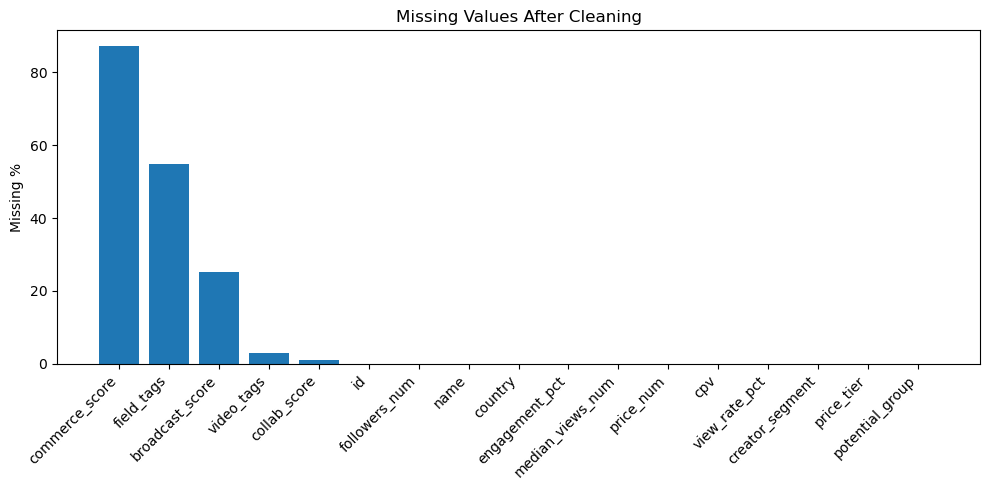

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(missing_after_cleaning.index, missing_after_cleaning["missing_pct"])
plt.title("Missing Values After Cleaning")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Creator Segment Distribution

In [5]:
segment_count = (
    df["creator_segment"]
    .value_counts()
    .reset_index()
)

segment_count.columns = ["creator_segment", "total_influencers"]

segment_count

,creator_segment,total_influencers
0,Mega,656
1,Macro,346
2,Mid-tier,146
3,Micro,1


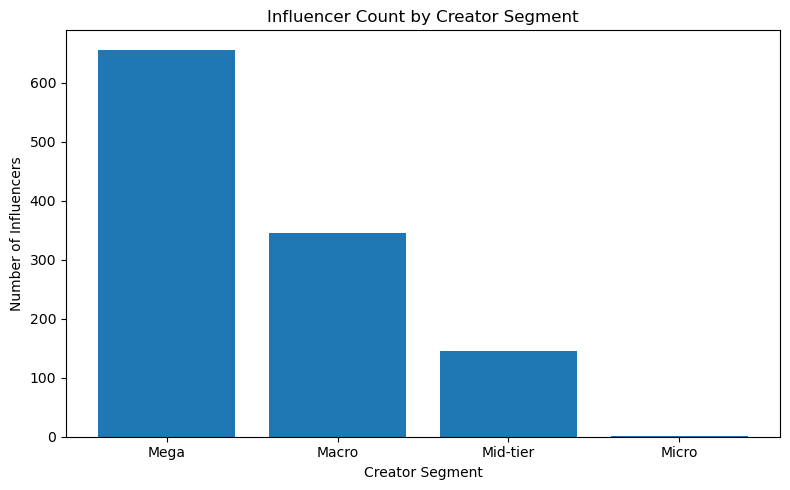

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(segment_count["creator_segment"], segment_count["total_influencers"])
plt.title("Influencer Count by Creator Segment")
plt.xlabel("Creator Segment")
plt.ylabel("Number of Influencers")
plt.tight_layout()
plt.show()

## 4. Price Tier Distribution

In [7]:
price_tier_count = (
    df["price_tier"]
    .value_counts()
    .reset_index()
)

price_tier_count.columns = ["price_tier", "total_influencers"]

price_tier_count

,price_tier,total_influencers
0,Low,425
1,Medium,411
2,High,248
3,Premium,65


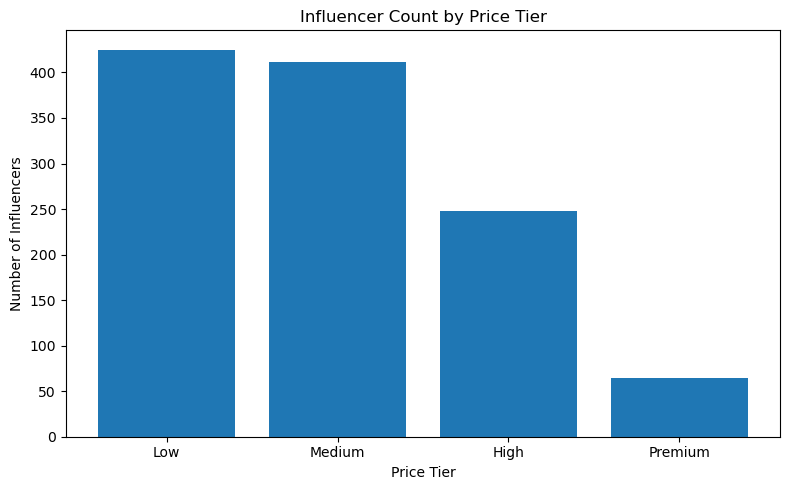

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(price_tier_count["price_tier"], price_tier_count["total_influencers"])
plt.title("Influencer Count by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Number of Influencers")
plt.tight_layout()
plt.show()

## 5. Followers Distribution

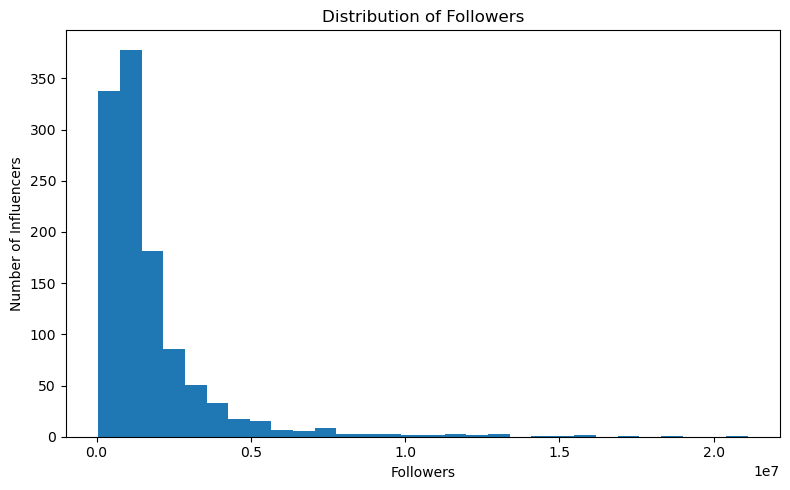

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["followers_num"].dropna(), bins=30)
plt.title("Distribution of Followers")
plt.xlabel("Followers")
plt.ylabel("Number of Influencers")
plt.tight_layout()
plt.show()

Followers are highly right-skewed because a small number of influencers have extremely large audiences.

## 6. Median Views Distribution

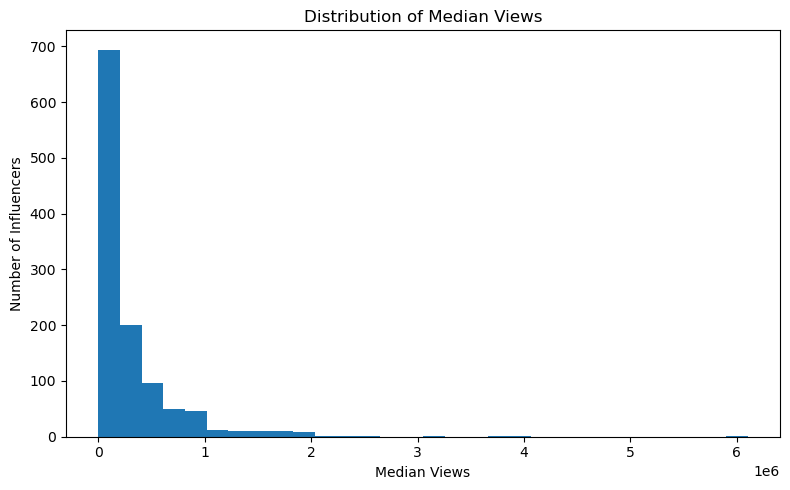

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["median_views_num"].dropna(), bins=30)
plt.title("Distribution of Median Views")
plt.xlabel("Median Views")
plt.ylabel("Number of Influencers")
plt.tight_layout()
plt.show()

## 7. Engagement Distribution

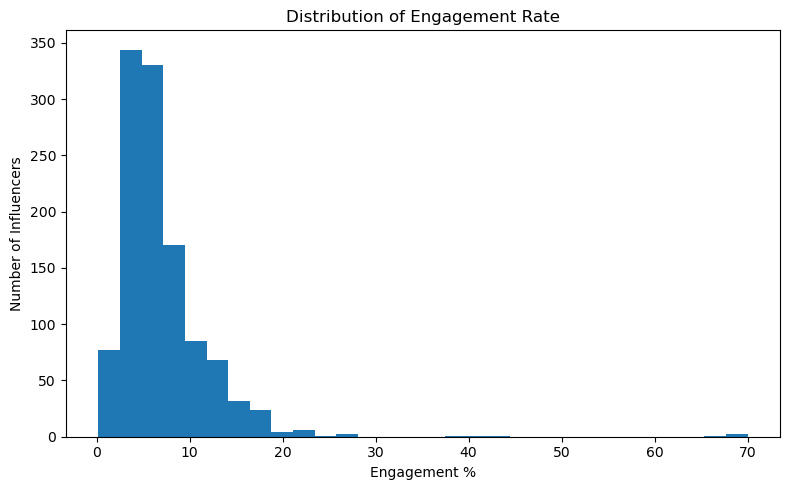

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["engagement_pct"].dropna(), bins=30)
plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement %")
plt.ylabel("Number of Influencers")
plt.tight_layout()
plt.show()

## 8. Price Distribution

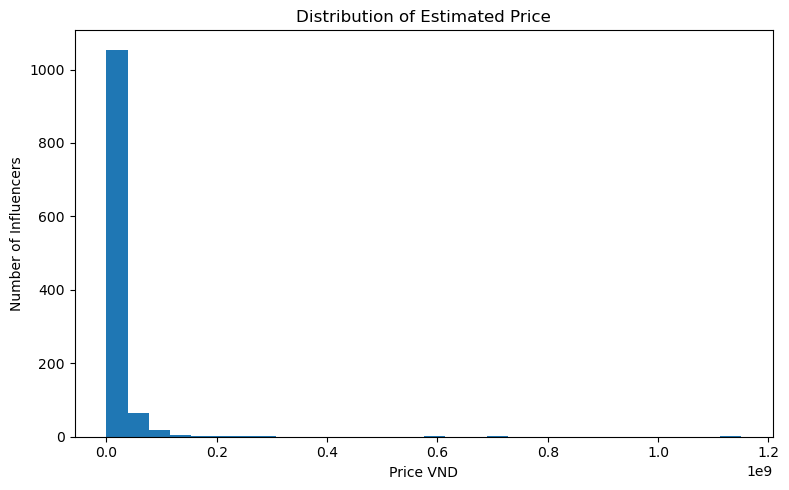

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["price_num"].dropna(), bins=30)
plt.title("Distribution of Estimated Price")
plt.xlabel("Price VND")
plt.ylabel("Number of Influencers")
plt.tight_layout()
plt.show()

## 9. Segment Performance Summary

In [13]:
segment_summary = (
    df
    .groupby("creator_segment")
    .agg(
        total_influencers=("id", "nunique"),
        avg_followers=("followers_num", "mean"),
        avg_median_views=("median_views_num", "mean"),
        avg_engagement=("engagement_pct", "mean"),
        median_price=("price_num", "median"),
        median_cpv=("cpv", "median")
    )
    .reset_index()
)

segment_summary

,creator_segment,total_influencers,avg_followers,avg_median_views,avg_engagement,median_price,median_cpv
0,Macro,346,"737,060.26","194,222.27",7.62,"4,962,831.50",42.06
1,Mega,656,"2,633,689.02","391,926.67",5.49,"10,000,000.00",44.07
2,Micro,1,"55,700.00","195,950.00",70.00,"500,000.00",2.55
3,Mid-tier,146,"357,015.41","132,902.40",12.15,"4,466,009.00",59.32


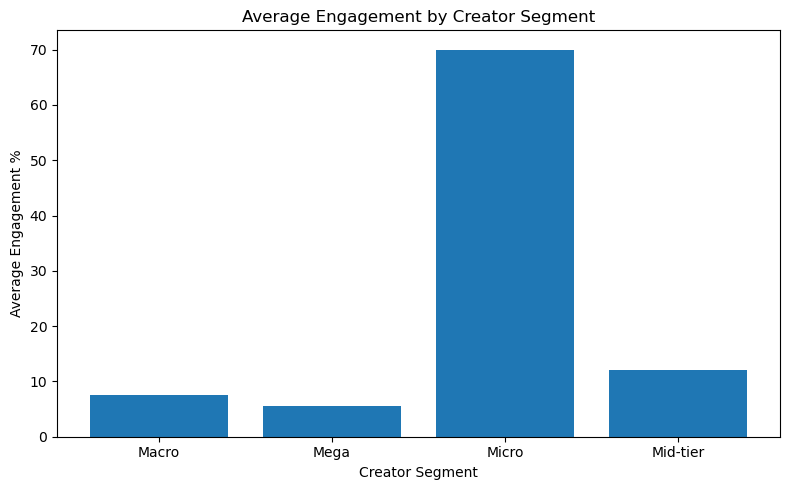

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(segment_summary["creator_segment"], segment_summary["avg_engagement"])
plt.title("Average Engagement by Creator Segment")
plt.xlabel("Creator Segment")
plt.ylabel("Average Engagement %")
plt.tight_layout()
plt.show()

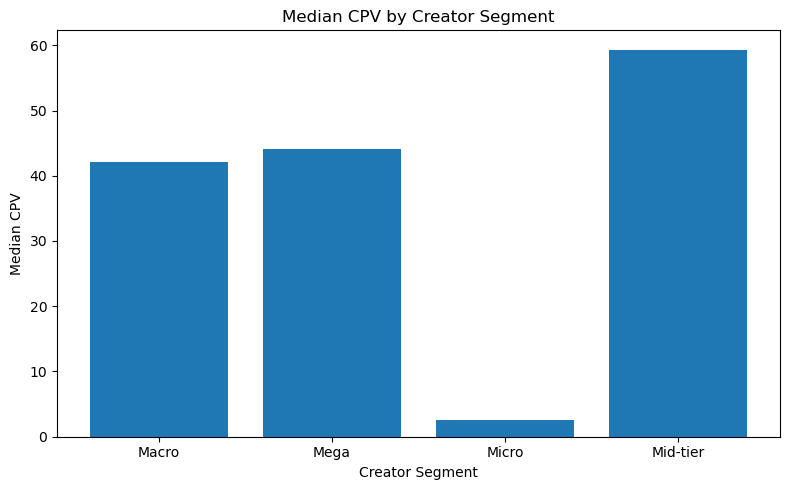

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(segment_summary["creator_segment"], segment_summary["median_cpv"])
plt.title("Median CPV by Creator Segment")
plt.xlabel("Creator Segment")
plt.ylabel("Median CPV")
plt.tight_layout()
plt.show()

## 10. Followers vs Median Views

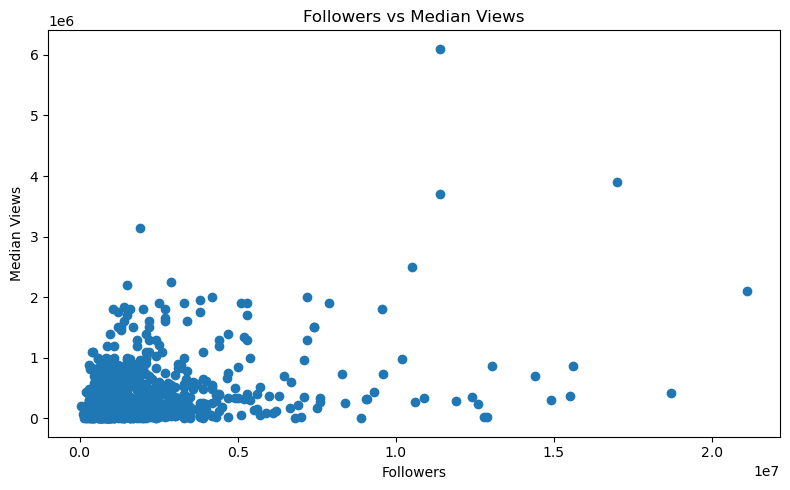

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df["followers_num"], df["median_views_num"])
plt.title("Followers vs Median Views")
plt.xlabel("Followers")
plt.ylabel("Median Views")
plt.tight_layout()
plt.show()

If the number of followers increases but the median views don't increase proportionally, the follower count isn't enough to evaluate the influencer.

## 11. Price vs Median Views

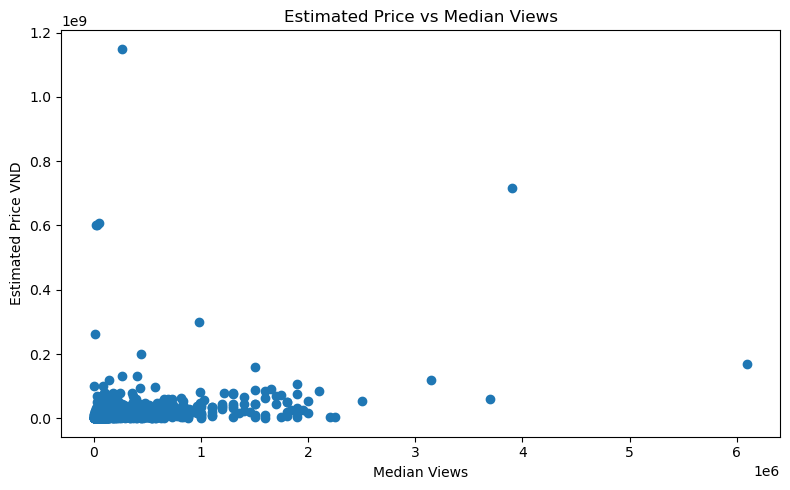

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df["median_views_num"], df["price_num"])
plt.title("Estimated Price vs Median Views")
plt.xlabel("Median Views")
plt.ylabel("Estimated Price VND")
plt.tight_layout()
plt.show()

Influencers with similar median views can have very different estimated prices, so CPV is needed for cost-efficiency analysis.

## 12. Potential Group Analysis

In [18]:
potential_summary = (
    df
    .groupby("potential_group")
    .agg(
        total_influencers=("id", "nunique"),
        avg_followers=("followers_num", "mean"),
        avg_median_views=("median_views_num", "mean"),
        avg_engagement=("engagement_pct", "mean"),
        median_price=("price_num", "median"),
        median_cpv=("cpv", "median")
    )
    .reset_index()
    .sort_values("total_influencers", ascending=False)
)

potential_summary

,potential_group,total_influencers,avg_followers,avg_median_views,avg_engagement,median_price,median_cpv
4,General / Low Priority,767,"1,731,986.25","218,769.95",6.27,"7,000,000.00",55.23
3,Cost-efficient,163,"2,151,214.11","632,860.43",6.33,"5,007,720.00",14.29
2,Collab-ready,129,"1,244,076.74","209,431.01",10.98,"6,376,854.00",56.82
1,Awareness Booster,50,"2,399,366.00","814,714.00",8.89,"17,368,403.00",27.98
5,High Reach - Low Efficiency,27,"1,655,568.52","85,670.37",9.49,"10,000,000.00",216.94
0,All-round Potential,12,"2,513,658.33","233,783.33",9.67,"9,500,000.00",46.76
6,Sales Potential,1,"503,000.00","80,900.00",10.63,"3,022,422.00",37.36


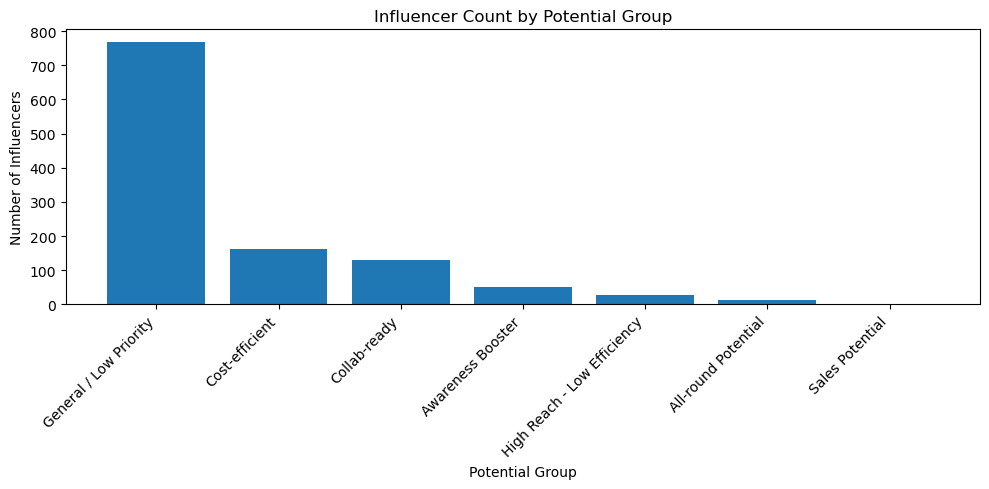

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(potential_summary["potential_group"], potential_summary["total_influencers"])
plt.title("Influencer Count by Potential Group")
plt.xlabel("Potential Group")
plt.ylabel("Number of Influencers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Sales Potential is limited because Commerce Score has many missing values.

## 13. Top Cost-efficient Influencers

In [20]:
top_cost_efficient = (
    df[df["cpv"].notna()]
    .sort_values(["cpv", "median_views_num"], ascending=[True, False])
    [
        [
            "name",
            "followers_num",
            "median_views_num",
            "engagement_pct",
            "price_num",
            "cpv",
            "creator_segment",
            "potential_group"
        ]
    ]
    .head(20)
)

top_cost_efficient

,name,followers_num,median_views_num,engagement_pct,price_num,cpv,creator_segment,potential_group
524,LC Nhất,"3,400,000.00","1,600,000.00",3.17,"50,000.00",0.03,Mega,Cost-efficient
483,Kha Khờ Khạo...dân63☑️,"820,750.00","94,100.00",5.93,"20,000.00",0.21,Macro,General / Low Priority
583,KimmyYay,"868,450.00","70,700.00",10.69,"30,000.00",0.42,Macro,General / Low Priority
202,Nguyễn Thành Công,"811,600.00","455,750.00",12.27,"200,000.00",0.44,Macro,Awareness Booster
1104,Vương Khánh,"2,500,000.00","360,600.00",4.57,"160,000.00",0.44,Mega,Cost-efficient
785,Phát La,"1,500,000.00","998,350.00",5.08,"500,000.00",0.50,Mega,Cost-efficient
20,Cấn Xuân Huy,"998,700.00","293,600.00",4.33,"160,000.00",0.54,Macro,Cost-efficient
582,Lưu Trung TV 🦁,"1,500,000.00","626,600.00",8.60,"352,731.00",0.56,Mega,Awareness Booster
552,Linh Chii🐱,"507,500.00","63,350.00",17.74,"40,000.00",0.63,Macro,General / Low Priority
570,Long Chun🎭,"7,600,000.00","333,450.00",4.20,"263,075.00",0.79,Mega,Cost-efficient


## 14. Top Awareness Influencers

In [21]:
top_awareness = (
    df[df["broadcast_score"].notna()]
    .sort_values(
        ["broadcast_score", "median_views_num", "cpv"],
        ascending=[False, False, True]
    )
    [
        [
            "name",
            "followers_num",
            "median_views_num",
            "broadcast_score",
            "engagement_pct",
            "price_num",
            "cpv",
            "potential_group"
        ]
    ]
    .head(20)
)

top_awareness

,name,followers_num,median_views_num,broadcast_score,engagement_pct,price_num,cpv,potential_group
414,Hương Thù,"761,200.00","701,400.00",100.00,12.61,"37,442,914.00",53.38,Awareness Booster
202,Nguyễn Thành Công,"811,600.00","455,750.00",100.00,12.27,"200,000.00",0.44,Awareness Booster
303,Trâm Ngọc,"277,900.00","415,900.00",100.00,19.63,"7,720,847.00",18.56,Awareness Booster
900,Nguyễn Văn Tài,"15,500,000.00","365,550.00",100.00,7.03,"30,000,000.00",82.07,Awareness Booster
68,Animexd1650™,"856,400.00","194,400.00",100.00,23.35,"2,632,000.00",13.54,Cost-efficient
728,A Nha Ngô,"267,900.00","107,300.00",100.00,8.15,"8,295,524.00",77.31,Collab-ready
1111,William家伙🇨🇳,"2,600,000.00","67,100.00",100.00,14.53,"1,088,537.00",16.22,General / Low Priority
262,Đức Thắng Ds,"1,900,000.00","56,900.00",100.00,4.68,"1,316,000.00",23.13,General / Low Priority
692,khanhpink,"1,100,000.00","56,600.00",100.00,7.69,"9,644,892.00",170.40,High Reach - Low Efficiency
898,𝙆𝙤_小麦🌸,"380,700.00","101,700.00",99.40,17.68,"10,000,000.00",98.33,High Reach - Low Efficiency


## 15. Top Sales Potential Influencers

In [22]:
top_sales = (
    df[df["commerce_score"].notna()]
    .sort_values(
        ["commerce_score", "engagement_pct", "cpv"],
        ascending=[False, False, True]
    )
    [
        [
            "name",
            "median_views_num",
            "engagement_pct",
            "commerce_score",
            "price_num",
            "cpv",
            "potential_group"
        ]
    ]
    .head(20)
)

top_sales

,name,median_views_num,engagement_pct,commerce_score,price_num,cpv,potential_group
853,Ruby Đẹp Trai,"92,650.00",18.44,100.00,"9,000,000.00",97.14,All-round Potential
882,Thuỷ Sophia,"101,000.00",9.03,100.00,"19,000,000.00",188.12,Collab-ready
944,Thị Nhung,"959,200.00",5.05,100.00,"20,000,000.00",20.85,All-round Potential
713,Thanh Tuyến🐰,"226,250.00",2.88,100.00,"25,000,000.00",110.50,General / Low Priority
1042,Thanh Tuyền_🥟,"410,300.00",2.72,100.00,"15,000,000.00",36.56,General / Low Priority
682,Nguyễn Đan Phương🖤,"24,550.00",2.65,100.00,"50,000,000.00","2,036.66",General / Low Priority
374,𝙃𝙤̀𝙖 𝙍𝙪𝙗𝙮,"869,450.00",4.58,99.60,"30,000,000.00",34.50,General / Low Priority
754,Nhật Linh đời thường🩴,"139,400.00",7.40,99.20,"6,000,000.00",43.04,All-round Potential
144,Cá hề biết nhảy 🩵,"602,500.00",6.34,99.20,"3,000,000.00",4.98,Collab-ready
949,Thư Wibu 🎀,"11,250.00",5.20,99.20,"10,000,000.00",888.89,General / Low Priority


# 16. Correlation Matrix

In [23]:
corr_cols = [
    "followers_num",
    "median_views_num",
    "engagement_pct",
    "price_num",
    "cpv",
    "view_rate_pct",
    "collab_score",
    "broadcast_score",
    "commerce_score"
]

corr_matrix = df[corr_cols].corr()

corr_matrix

,followers_num,median_views_num,engagement_pct,price_num,cpv,view_rate_pct,collab_score,broadcast_score,commerce_score
followers_num,1.00,0.38,-0.18,0.24,-0.01,-0.17,0.05,-0.11,0.08
median_views_num,0.38,1.00,-0.07,0.25,-0.06,0.51,-0.08,-0.06,0.06
engagement_pct,-0.18,-0.07,1.00,-0.00,0.03,0.20,0.08,0.31,0.15
price_num,0.24,0.25,-0.00,1.00,0.40,0.05,-0.03,-0.00,0.13
cpv,-0.01,-0.06,0.03,0.40,1.00,-0.06,0.01,0.04,0.24
view_rate_pct,-0.17,0.51,0.20,0.05,-0.06,1.00,-0.05,0.09,-0.07
collab_score,0.05,-0.08,0.08,-0.03,0.01,-0.05,1.00,0.24,0.44
broadcast_score,-0.11,-0.06,0.31,-0.00,0.04,0.09,0.24,1.00,0.15
commerce_score,0.08,0.06,0.15,0.13,0.24,-0.07,0.44,0.15,1.00


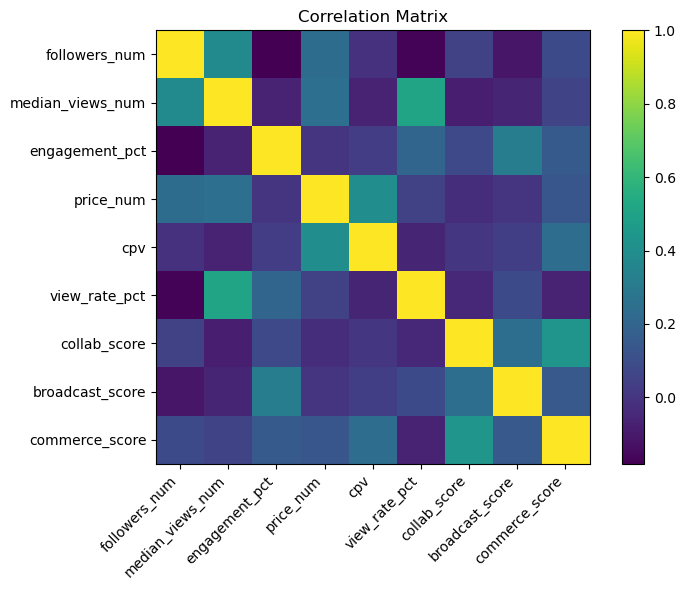

In [24]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()